<a href="https://colab.research.google.com/github/keshariujjwal51/Ujjwal/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [3]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Flattened train shape:", x_train_flat.shape)


Flattened train shape: (50000, 3072)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Data loading and preprocessing to ensure x_train_flat and y_train are defined
# (x_train, y_train), (x_test, y_test) are loaded and preprocessed in previous cells.
# Adding these steps here ensures the cell runs even if previous steps were skipped.
(x_train_raw, y_train_raw), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train_norm = x_train_raw / 255.0
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
y_train = y_train_raw.flatten()

ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2666 - loss: 1.9992 - val_accuracy: 0.3048 - val_loss: 1.8700
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3082 - loss: 1.8823 - val_accuracy: 0.3612 - val_loss: 1.8103
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3256 - loss: 1.8399 - val_accuracy: 0.3416 - val_loss: 1.8057
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3416 - loss: 1.8013 - val_accuracy: 0.3692 - val_loss: 1.7581
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3456 - loss: 1.7892 - val_accuracy: 0.3842 - val_loss: 1.7392
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3520 - loss: 1.7692 - val_accuracy: 0.4008 - val_loss: 1.7090
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3668 - loss: 1.7420 - val_accuracy: 0.3930 - val_loss: 1.7081
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/ste

In [6]:
# Load test data and preprocess if not already available in the current scope
# This ensures x_test_flat and y_test are defined for evaluation.
if 'x_test_flat' not in locals() or 'y_test' not in locals():
    # Only load the test part of the dataset, as train might already be loaded by kV77s9yok-pT
    # or other cells.
    (_, _), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()
    x_test_norm = x_test_raw / 255.0
    x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)
    y_test = y_test_raw.flatten()

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("Baseline ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4153 - loss: 1.6567
Baseline ANN Test Accuracy: 0.41530001163482666


In [7]:
def build_cnn():
    """Returns a freshly-compiled CNN with the 32 -> 64 -> 128 filter progression."""
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu'),   # Filter stage 1: 32
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),   # Filter stage 2: 64
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),  # Filter stage 3: 128
        layers.BatchNormalization(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

build_cnn().summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
cnn_model = build_cnn()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4736 - loss: 1.5558 - val_accuracy: 0.5100 - val_loss: 1.3719
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6239 - loss: 1.0719 - val_accuracy: 0.5580 - val_loss: 1.2790
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6842 - loss: 0.8981 - val_accuracy: 0.6276 - val_loss: 1.1283
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7230 - loss: 0.7864 - val_accuracy: 0.6706 - val_loss: 0.9665
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7541 - loss: 0.6946 - val_accuracy: 0.6748 - val_loss: 1.0037
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7821 - loss: 0.6177 - val_accuracy: 0.6316 - val_loss: 1.2179
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8008 - loss: 0.5615 - val_accuracy: 0.6994 - val_loss: 0.9125
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8239 - loss: 0.4983 - val_accuracy: 

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("Baseline CNN Test Accuracy:", cnn_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7135 - loss: 0.9528
Baseline CNN Test Accuracy: 0.7135000228881836


In [10]:
ann_deep_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2514 - loss: 2.0181 - val_accuracy: 0.3054 - val_loss: 1.8943
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3143 - loss: 1.8764 - val_accuracy: 0.3244 - val_loss: 1.8716
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3300 - loss: 1.8343 - val_accuracy: 0.3742 - val_loss: 1.7731
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3453 - loss: 1.7940 - val_accuracy: 0.3632 - val_loss: 1.7842
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3576 - loss: 1.7676 - val_accuracy: 0.3790 - val_loss: 1.7326
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3637 - loss: 1.7446 - val_accuracy: 0.3964 - val_loss: 1.7035
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3719 - loss: 1.7265 - val_accuracy: 0.3986 - val_loss: 1.6780
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3798 - loss: 1.7158 - val_accuracy: 0.

In [11]:
ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("Deep ANN Test Accuracy:", ann_deep_test_acc)

print("\nComparison:")
print(f"Baseline ANN Test Accuracy : {ann_test_acc:.4f}")
print(f"Deep ANN Test Accuracy     : {ann_deep_test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4274 - loss: 1.6433
Deep ANN Test Accuracy: 0.42739999294281006

Comparison:
Baseline ANN Test Accuracy : 0.4153
Deep ANN Test Accuracy     : 0.4274


In [12]:
print("CNN filter progression: 32 -> 64 -> 128\n")
build_cnn().summary()


CNN filter progression: 32 -> 64 -> 128



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
cnn_epoch20_model = build_cnn()

cnn_epoch20_history = cnn_epoch20_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4920 - loss: 1.5072 - val_accuracy: 0.5540 - val_loss: 1.2605
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6281 - loss: 1.0577 - val_accuracy: 0.5992 - val_loss: 1.1356
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6860 - loss: 0.8955 - val_accuracy: 0.6786 - val_loss: 0.9086
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7242 - loss: 0.7868 - val_accuracy: 0.6646 - val_loss: 0.9981
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7565 - loss: 0.7013 - val_accuracy: 0.6702 - val_loss: 1.0448
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7788 - loss: 0.6268 - val_accuracy: 0.7084 - val_loss: 0.8862
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8007 - loss: 0.5652 - val_accuracy: 0.6268 - val_loss: 1.1739
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8202 - loss: 0.5101 - val_accuracy: 

In [14]:
cnn_epoch20_test_loss, cnn_epoch20_test_acc = cnn_epoch20_model.evaluate(x_test_norm, y_test)
print("CNN (20 Epochs) Test Accuracy:", cnn_epoch20_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6861 - loss: 1.3593
CNN (20 Epochs) Test Accuracy: 0.6861000061035156


In [15]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_earlystop_model = build_cnn()

cnn_earlystop_history = cnn_earlystop_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

print(f"\nTraining stopped after {len(cnn_earlystop_history.history['loss'])} epochs (max was 20).")


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4817 - loss: 1.5317 - val_accuracy: 0.4144 - val_loss: 1.7139
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6223 - loss: 1.0791 - val_accuracy: 0.6338 - val_loss: 1.0334
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6827 - loss: 0.9037 - val_accuracy: 0.6680 - val_loss: 0.9571
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7206 - loss: 0.7977 - val_accuracy: 0.6196 - val_loss: 1.1090
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7493 - loss: 0.7117 - val_accuracy: 0.7164 - val_loss: 0.7959
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7766 - loss: 0.6344 - val_accuracy: 0.6582 - val_loss: 1.1080
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7967 - loss: 0.5747 - val_accuracy: 0.7044 - val_loss: 0.8686
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8162 - loss: 0.5214 - val_accuracy: 

In [17]:
cnn_earlystop_test_loss, cnn_earlystop_test_acc = cnn_earlystop_model.evaluate(x_test_norm, y_test)
print("CNN + EarlyStopping Test Accuracy:", cnn_earlystop_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7132 - loss: 0.8399
CNN + EarlyStopping Test Accuracy: 0.7131999731063843


In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_aug = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_cnn_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug]
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4277 - loss: 1.6745 - val_accuracy: 0.5608 - val_loss: 1.2649
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5295 - loss: 1.3319 - val_accuracy: 0.5824 - val_loss: 1.1765
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5707 - loss: 1.2151 - val_accuracy: 0.6210 - val_loss: 1.0877
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6012 - loss: 1.1410 - val_accuracy: 0.5876 - val_loss: 1.1302
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6200 - loss: 1.0880 - val_accuracy: 0.5728 - val_loss: 1.2481
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6407 - loss: 1.0368 - val_accuracy: 0.6128 - val_loss: 1.1486


In [19]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("CNN + Data Augmentation Test Accuracy:", aug_cnn_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6134 - loss: 1.0981
CNN + Data Augmentation Test Accuracy: 0.6133999824523926


##Final Comparison — All Models


In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ANN (Baseline)",
        "ANN (Deep - Task 1)",
        "CNN (Filters 32-64-128 - Task 2, 10 Epochs)",
        "CNN (20 Epochs - Task 3)",
        "CNN + EarlyStopping (Task 4)",
        "CNN + Augmentation + EarlyStopping (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        ann_deep_test_acc,
        cnn_test_acc,
        cnn_epoch20_test_acc,
        cnn_earlystop_test_acc,
        aug_cnn_test_acc
    ]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

comparison

,Model,Test Accuracy
0,"CNN (Filters 32-64-128 - Task 2, 10 Epochs)",0.7135
1,CNN + EarlyStopping (Task 4),0.7132
2,CNN (20 Epochs - Task 3),0.6861
3,CNN + Augmentation + EarlyStopping (Task 5),0.6134
4,ANN (Deep - Task 1),0.4274
5,ANN (Baseline),0.4153


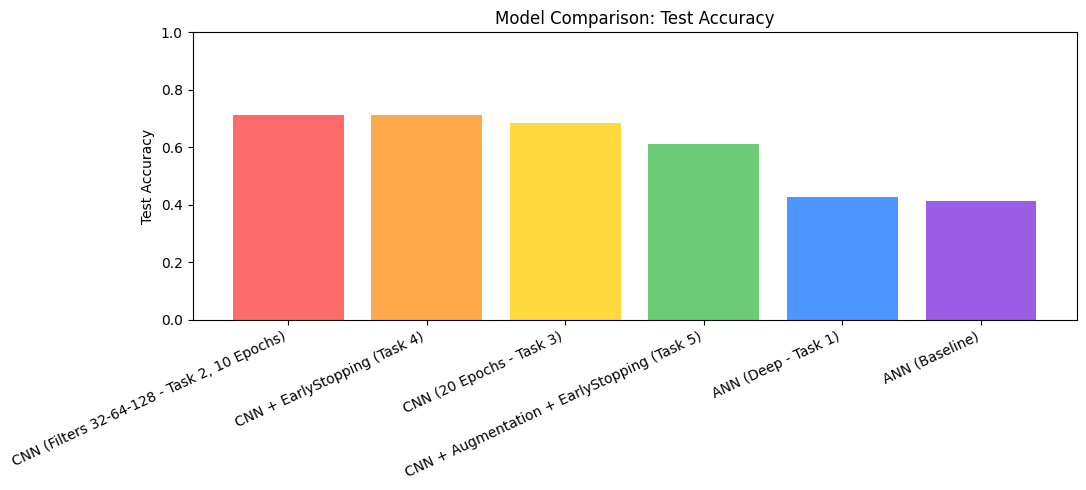

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))
colors = ['#FF6B6B', '#FFA94D', '#FFD93D', '#6BCB77', '#4D96FF', '#9B5DE5']
plt.bar(comparison["Model"], comparison["Test Accuracy"], color=colors[:len(comparison)])
plt.ylabel("Test Accuracy")
plt.title("Model Comparison: Test Accuracy")
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

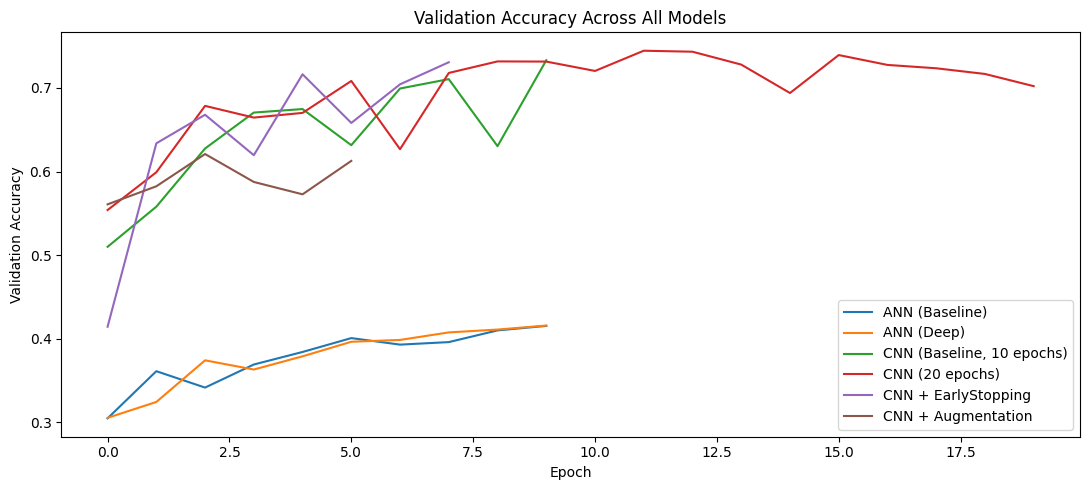

In [24]:
plt.figure(figsize=(11, 5))
plt.plot(ann_history.history['val_accuracy'], label='ANN (Baseline)')
plt.plot(ann_deep_history.history['val_accuracy'], label='ANN (Deep)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (Baseline, 10 epochs)')
plt.plot(cnn_epoch20_history.history['val_accuracy'], label='CNN (20 epochs)')
plt.plot(cnn_earlystop_history.history['val_accuracy'], label='CNN + EarlyStopping')
plt.plot(aug_cnn_history.history['val_accuracy'], label='CNN + Augmentation')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across All Models")
plt.legend()
plt.tight_layout()
plt.show()


## ✅ Conclusion

- **ANN works, but ignores image structure** — even after adding more layers (Task 1), the ANN's accuracy gain is limited, because flattening the image throws away spatial relationships between neighboring pixels.
- **CNN extracts spatial features, so it performs significantly better** — the convolutional filter progression (32 → 64 → 128, Task 2) lets the network build up from simple edges to complex shapes, far outperforming the ANN.
- **Training strategies like dropout, batch norm, and augmentation improve results** — increasing epochs alone (Task 3) can lead to overfitting; **EarlyStopping** (Task 4) protects against this automatically, and **data augmentation** (Task 5) further improves generalization by exposing the model to more varied versions of the training images.
- **This project builds strong fundamentals for computer vision interviews and deep learning projects** — by experimenting hands-on with architecture depth, filter sizes, training duration, and regularization/augmentation strategies, this notebook reinforces *why* each design choice matters, not just *that* it works.

### 🔧 Next Steps to Explore Further
- Try `ReduceLROnPlateau` alongside EarlyStopping.
- Add a 4th convolutional block (256 filters) for an even deeper CNN.
- Try transfer learning with a pretrained model (e.g., `ResNet50`, `EfficientNetB0`) for a much bigger accuracy jump.
